In [1]:
# Gõ dòng này vào cell đầu tiên và bấm Run (Shift + Enter) or Run All
get_ipython().run_line_magic('run', '../_setup.py')

In [2]:
from typing import Optional

from IPython.display import Image
from matplotlib.ticker import MaxNLocator
from statsforecast import StatsForecast
from statsforecast.arima import ARIMASummary, ndiffs, nsdiffs
from statsforecast.models import ARIMA, AutoARIMA, AutoETS
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.stats.diagnostic import acorr_ljungbox
from statsmodels.tsa.stattools import kpss
from utilsforecast.losses import rmse, mae

In [3]:
BASE_DIR = Path.cwd().parent.parent
DATA_DIR = BASE_DIR / "data"
print(DATA_DIR)

/home/phu/Documents/GitHub/-Time-Series-Analysis-and-Forecasting-methods-/data


# Chapter 9 - ARIMA models 

ARIMA models provide another approach to time series forecasting. Exponential smoothing and ARIMA models are the two most widely used approaches to time series forecasting, and provide complementary approaches to the problem. While exponential smoothing models are based on a description of the trend and seasonality in the data, ARIMA models aim to describe the autocorrelations in the data.

Before we introduce ARIMA models, we must first discuss the concept of stationarity and the technique of differencing time series.

## 9.1 Stationarity and differencing (Tính dừng và Sai Phân)

> A stationary time series is one whose statistical properties do not depend on the time at which the series is observed.

Thus, time series  with trends, or with seasonality, are not stationary - the trend and seasonality will affect the value of the time series at different times. 

On the other hand, a white noise series is stationary - it does not matter when you observe it, it should look much the same at any point in time. 

In general, a stationary time series will have no predictable patterns in the long-term. Time plots will show the series to be roughly horizontal (although some cyclic behaviour is possible), with constant variance.

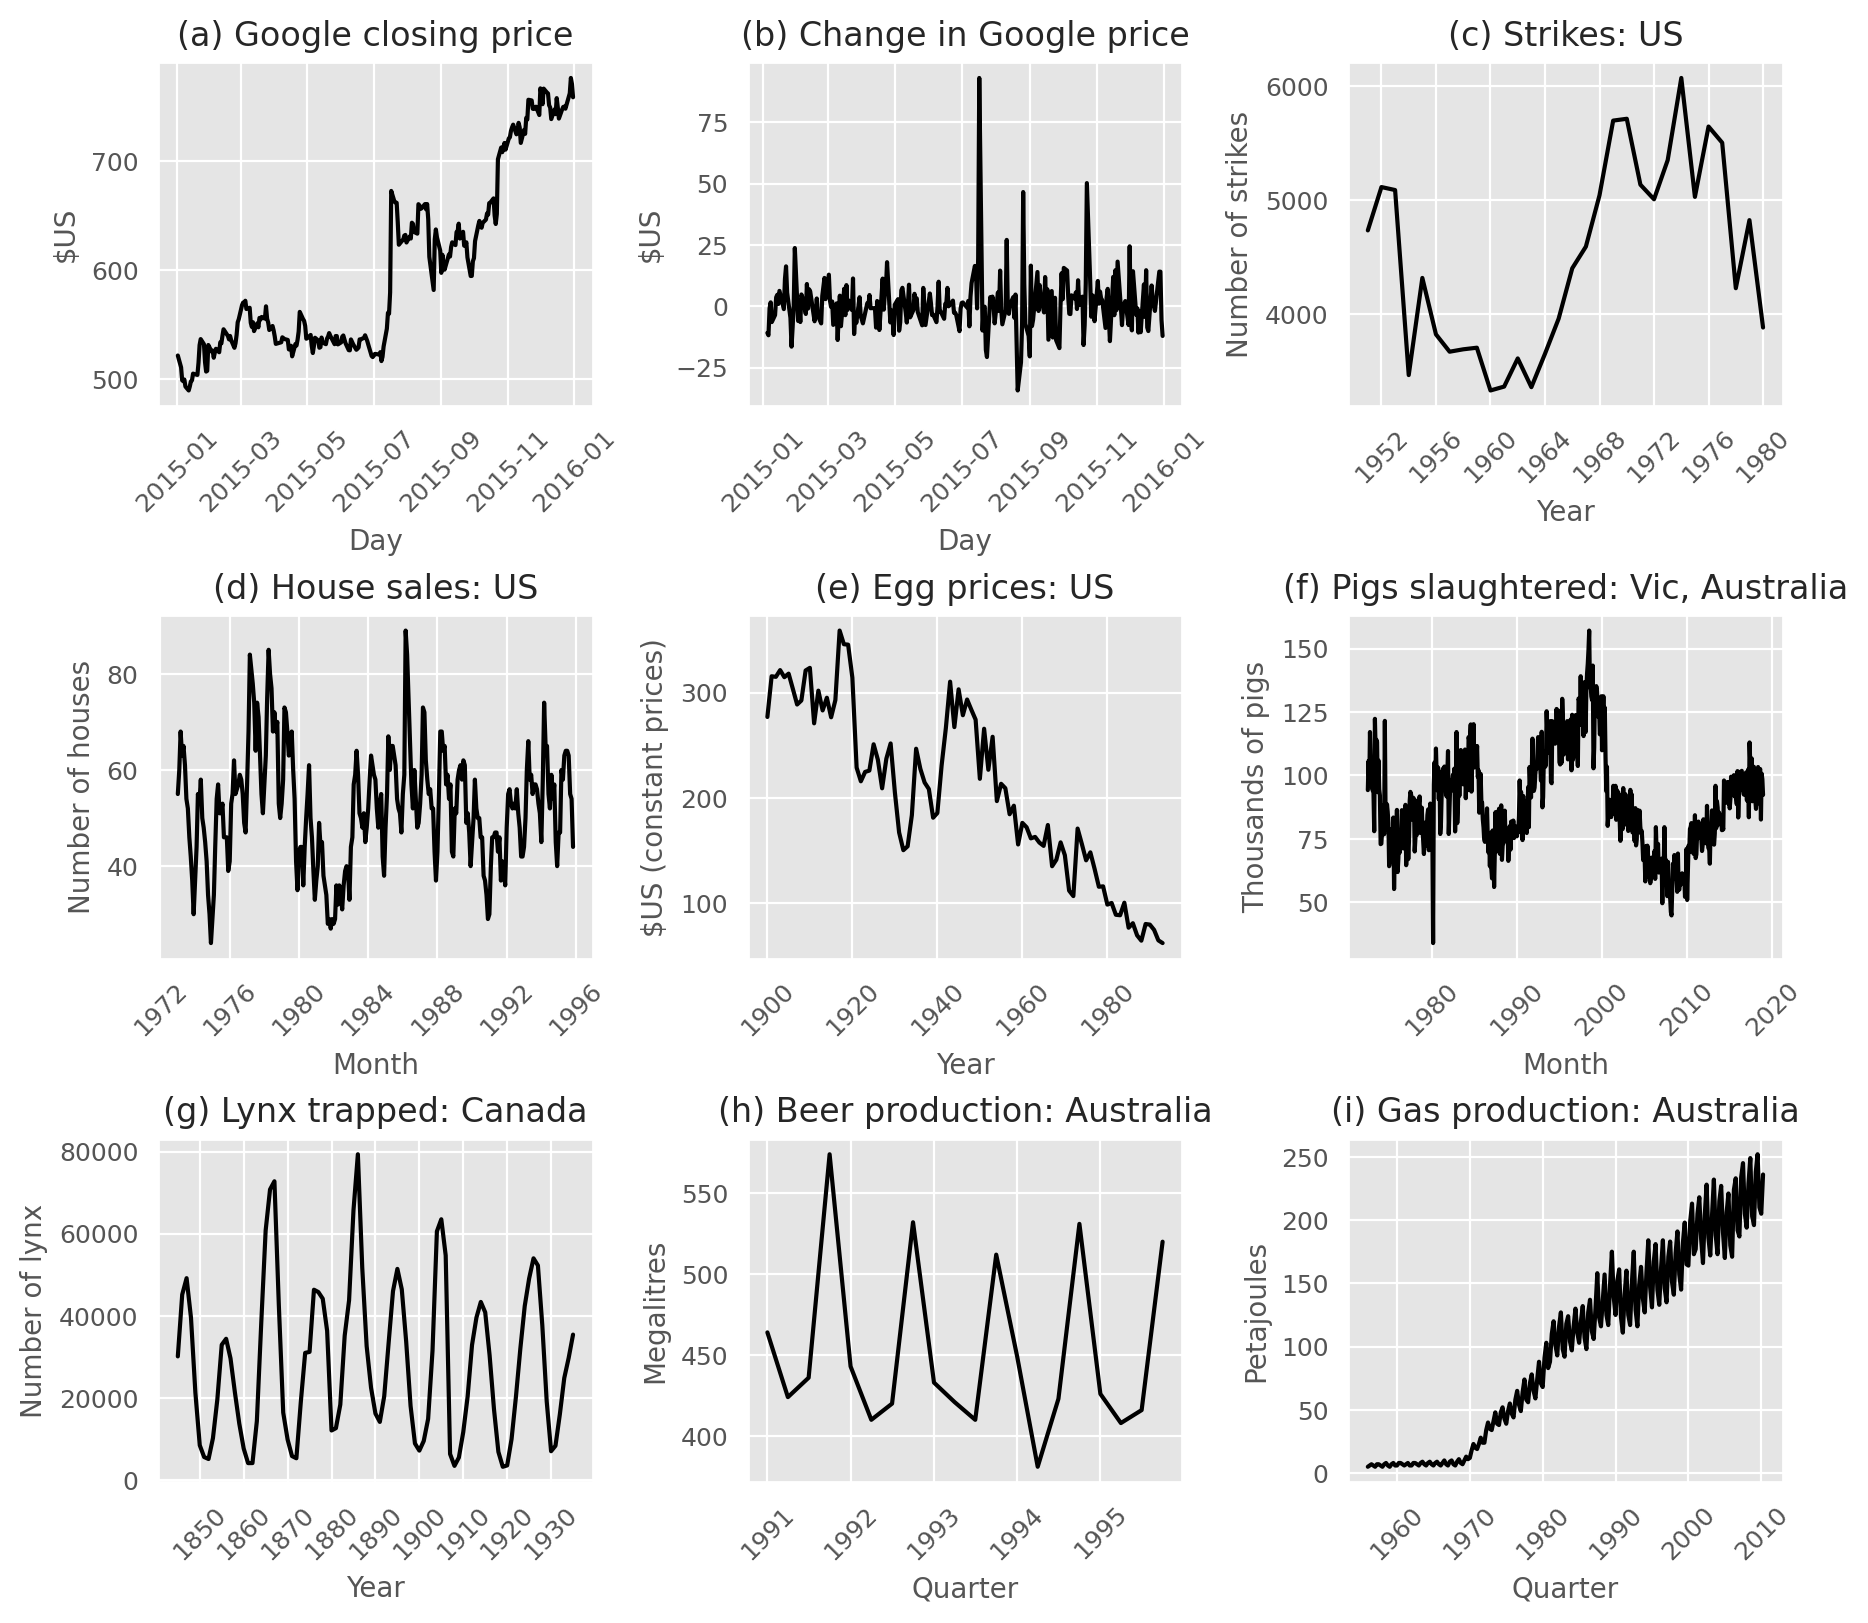
> Which of these series are stationary? (a) Google closing stock price in 2015; (b) Daily change in the Google stock price in 2015; (c) Annual number of strikes in the US; (d) Monthly sales of new one-family houses sold in the US; (e) Annual price of a dozen eggs in the US (constant dollars); (f) Monthly total of pigs slaughtered in Victoria, Australia; (g) Annual total of Canadian Lynx furs traded by the Hudson Bay Company; (h) Quarterly Australian beer production; (i) Monthly Australian gas production.

Seasonality: (d), (h), (i). Trend: (a), (c), (e), (f), (i). Increasing variance: (i). So, the stationary series is (b), (g).


### Differencing 

In above figure, note that the Google stock price was non-stationary in panel (a), but the daily changes were stationary in panel (b). 

To make  make a non-stationary time series stationary — compute the differences between consecutive observations (called **Differencing**).

Transformations such as logarithms can help to stabilise the variance of a time series. Differencing can help stabilise the mean of a time series by removing changes in the level of a time series, and therefore eliminating (or reducing) trend and seasonality.

As well as the time plot of the data, the ACF plot is also useful for identifying non-stationary time series. For a stationary time series, the ACF will drop to zero relatively quickly, while the ACF of non-stationary data decreases slowly. Also, for non-stationary data, the value of $r_1$ is often large and positive.

Cases of Differencing:
* First-order differencing: eliminate the linear trend. 
* Sencond-order differencing: If first-order differencing don't make a non-stationary time series stationary, we keep using differencing of the differenced series.
* Seasonal differencing: Subtract the value of the series from its corresponding value for the same period of the previous season (e.g., $y_t - y_{t-12}$ for monthly data) to remove seasonality.

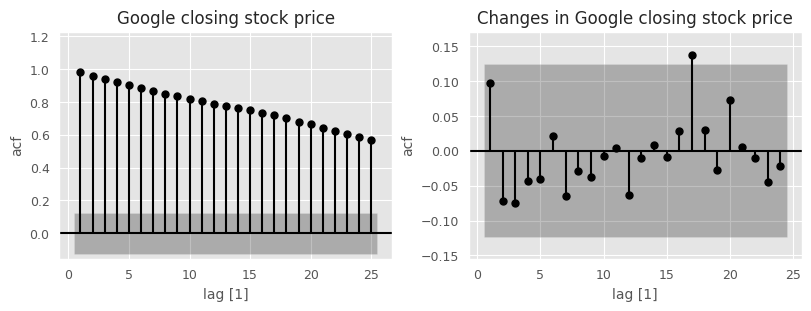

In [4]:
google = (
    pd.read_csv(DATA_DIR / "gafa_stock.csv", parse_dates=["ds"])
    .loc[lambda x: (x["unique_id"] == "GOOG_Close")
        & (x["ds"].dt.year == 2015)
    ]
    .reset_index()
)

fig, axes = plt.subplots(1, 2, figsize=(8, 3))
plot_acf(
    google["y"], ax=axes[0], zero=False,
    title="Google closing stock price",
    bartlett_confint=False, auto_ylims=True)
plot_acf(
    google["y"].diff().iloc[1:], ax=axes[1], zero=False,
    title="Changes in Google closing stock price",
    bartlett_confint=False, auto_ylims=True)
for ax in axes:
    ax.set(xlabel="lag [1]", ylabel="acf")
plt.show()

In [ ]:
ljung_box = acorr_ljungbox(google["y"].diff()[1:], lags=[10])
ljung_box

,lb_stat,lb_pvalue
10,7.914,0.637


The ACF of the differenced Google stock price looks just like that of a white noise series. Only one autocorrelation is outside of the 95% limits, and the Ljung-Box $Q^*$ statistic has a p-value of 0.637 (for $h=10$). This suggests that the daily change in the Google stock price is essentially a random amount which is uncorrelated with that of previous days.

### Random Walk model

The differenced series is the change between consecutive observations in the original series, and can be written as $$y'_t = y_t - y_{t-1}$$

The differenced series will have only $T−1$ values, since it is not possible to calculate a difference $y'_1$ for the first observation.

When the differenced series is white noise, the model for the original series can be written as $$y'_t = \epsilon_t$$
* Where $\epsilon_t$ denotes white noise. Rearranging this leads to the “random walk” model: $$y_t = y_{t-1} + \epsilon_t$$


Random walk models are widely used for non-stationary data, particularly financial and economic data. Random walks typically have:
* Long periods of apparent trends up or down
* Sudden and unpredictable changes in direction.

A closely related model allows the differences to have a non-zero mean. Then $$y_t - y_{t-1} = c + \epsilon_t ~~\text{or}~~ y_t = c + y_{t-1} + \epsilon_t$$ 
* The value of $c$ is the average of the changes between consecutive observations. If $c$ is positive, then the average change is an increase in the value of $y_t$. Thus, $y_t$ will tend to drift upwards. However, if $c$ is negative, $y_t$ will tend to drift downwards.

### Second-order differencing

Occasionally the differenced data will not appear to be stationary and it may be necessary to difference the data a second time to obtain a stationary series: 
$$\begin{aligned}
y''_t &= y'_t - y'_{t-1} \\
&= (y_t - y_{t-1}) - (y_{t-1} - y_{t-2}) \\
&= y_t - 2y_{t-1} + y_{t-2}
\end{aligned}$$

In this case, $y''$ will have $T−2$ values. Then, we would model the “change in the changes” of the original data. In practice, it is almost never necessary to go beyond second-order differences.

### Seasonal Differencing 
A seasonal difference is the difference between an observation and the previous observation from the same season. So $$y'_t = y_t - y_{t-m}$$
* where $m$ = the number of seasons. These are also called “lag-$m$ differences”, as we subtract the observation after a lag of $m$ periods.

If seasonally differenced data appear to be white noise, then an appropriate model for the original data is $$y_t = y_{t-m} + \epsilon_t$$

Forecasts from this model are equal to the last observation from the relevant season. That is, this model gives Seasonal Naïve forecast.

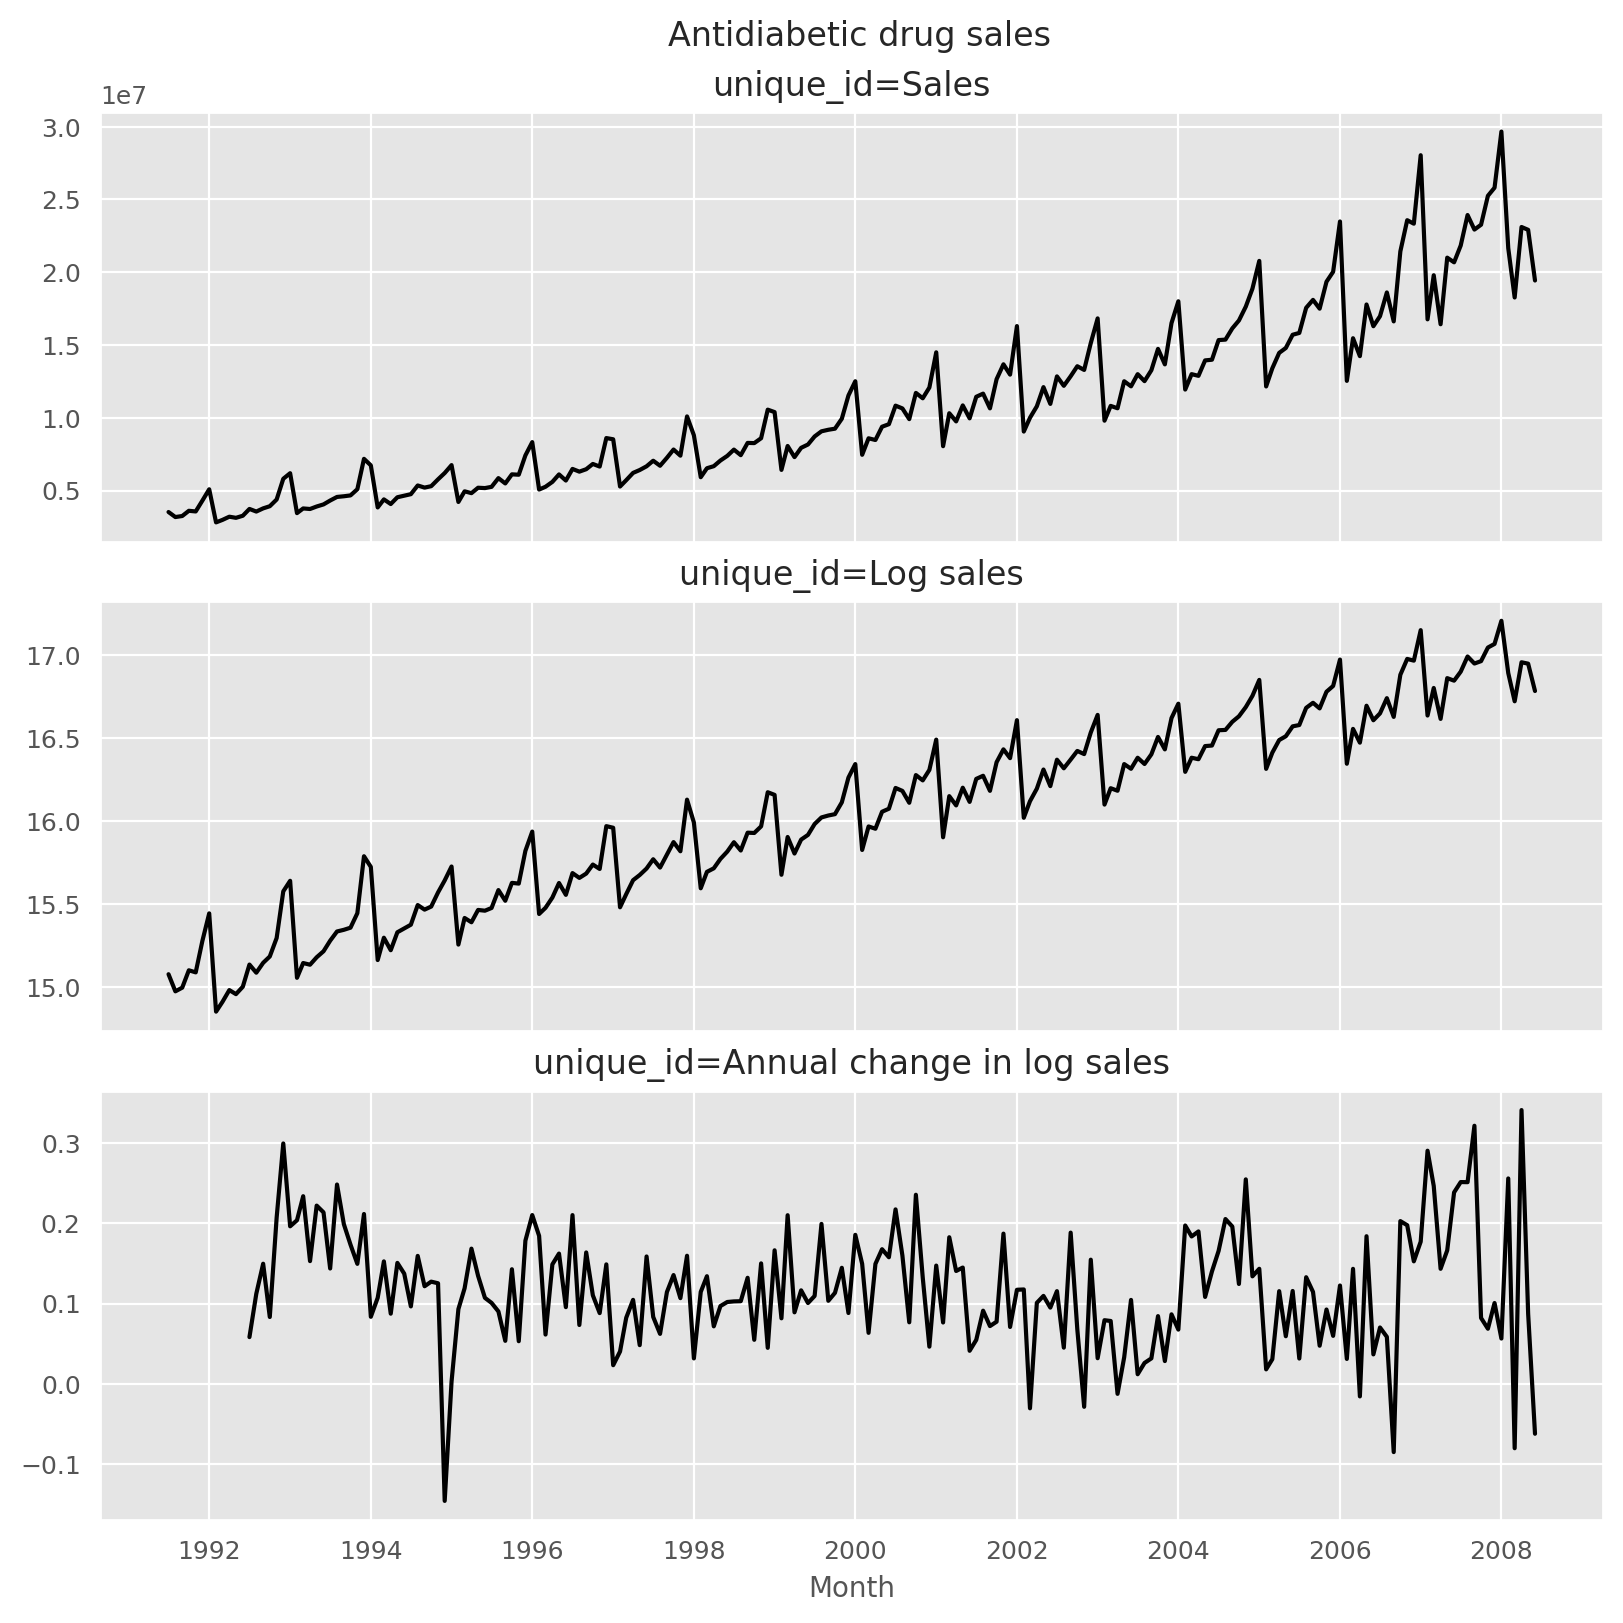
The bottom panel in above figure shows the seasonal differences of the logarithm of the monthly scripts for A10 (antidiabetic) drugs sold in Australia. The transformation and differencing have made the series look relatively stationary.



Sometimes it is necessary to take both a seasonal difference and a first difference to obtain stationary data. Figure 9.4 plots Australian corticosteroid drug sales ($AUD) (top panel). Here, the data are first transformed using logarithms (second panel), then seasonal differences are calculated (third panel). The data still seem somewhat non-stationary, and so a further lot of first differences are computed (bottom panel).

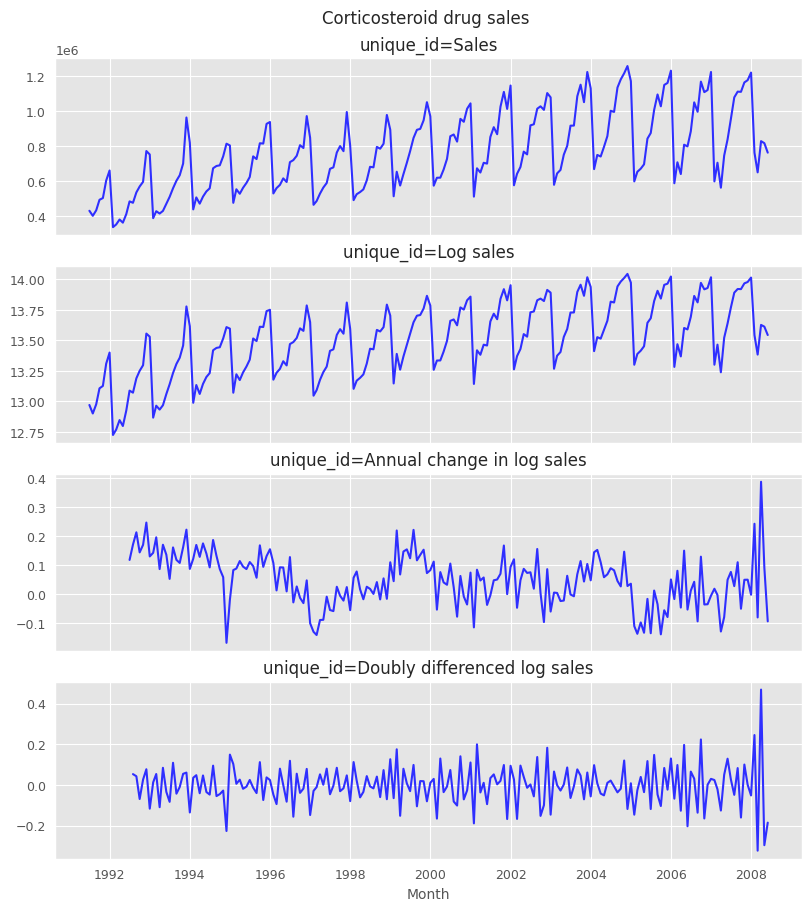

In [6]:
order = {
    "sales": 0, "log_sales": 1,
    "diff_log_sales": 2, "ddiff_log_sales": 3}
renames = {
    "sales": "Sales", "log_sales": "Log sales",
    "diff_log_sales": "Annual change in log sales",
    "ddiff_log_sales": "Doubly differenced log sales",
}
pbs = (
    pd.read_csv(DATA_DIR / "PBS_unparsed.csv", parse_dates=["Month"])
    .rename(columns={"Month": "ds"})
    .loc[lambda x: x["ATC2"] == "H02"]
    .groupby("ds")["Cost"].sum()
    .rename("sales").reset_index()
    .assign(
        log_sales=lambda x: np.log(x["sales"]),
        diff_log_sales=lambda x: x["log_sales"].diff(12),
        ddiff_log_sales=lambda x: x["diff_log_sales"].diff(),
    )
    # Rearrange into long form
    .melt(id_vars=["ds"], var_name="unique_id", value_name="y")
    .assign(order=lambda x: x["unique_id"].map(order))
    .sort_values(["order", "ds"])
    .assign(unique_id=lambda x: x["unique_id"].map(renames))
)

fig, axes = plt.subplots(4, figsize=(8, 9), sharex=True)
plot_series_utils(pbs, ax=axes)
for ax in axes:
    ax.set(ylabel="")
    if ax.get_legend():
        ax.get_legend().remove()
    for label in ax.get_xticklabels():
        label.set_rotation(0)
ax.set(xlabel="Month")
fig.legends = []
fig.suptitle("Corticosteroid drug sales", x=0.525)
fig

When both seasonal and first differences are applied, it makes no difference which is done first—the result will be the same. However, if the data have a strong seasonal pattern, we recommend that seasonal differencing be done first, because the resulting series will sometimes be stationary and there will be no need for a further first difference. If first differencing is done first, there will still be seasonality present.

> Beware that applying more differences than required will induce false dynamics or autocorrelations that do not really exist in the time series. Therefore, do as few differences as necessary to obtain a stationary series.

### Unit root tests

One way to determine more objectively whether differencing is required is to use a unit root test. These are statistical hypothesis tests of stationarity that are designed for **determining whether differencing is required**.

we use the Kwiatkowski-Phillips-Schmidt-Shin (KPSS) test (Kwiatkowski et al., 1992). In this test, the null hypothesis is that the data are stationary, and we look for evidence that the null hypothesis is false. Consequently, small p-values (e.g., less than 0.05) suggest that differencing is required. The test can be computed using the `kpss()` function.

In [7]:
kpss_stat, kpss_pvalue, *_ = kpss(google["y"], nlags = 5)
print(f"kpss_stat: {kpss_stat:.3f}")
print(f"kpss_pvalue: {kpss_pvalue:.2f}")

kpss_stat: 3.561
kpss_pvalue: 0.01


/tmp/ipykernel_473222/1367699554.py:1: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is smaller than the p-value returned.

  kpss_stat, kpss_pvalue, *_ = kpss(google["y"], nlags = 5)


In [8]:
# test again after differencing
kpss_stat, kpss_pvalue, *_ = kpss(google["y"].diff()[1:], nlags=5)
print(f"kpss_stat: {kpss_stat:.3f}")
print(f"kpss_pvalue: {kpss_pvalue:.2f}")

kpss_stat: 0.099
kpss_pvalue: 0.10


/tmp/ipykernel_473222/1114274133.py:2: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  kpss_stat, kpss_pvalue, *_ = kpss(google["y"].diff()[1:], nlags=5)


In [9]:
# This process of using a sequence of KPSS tests 
# to determine the appropriate number of first differences 
# is carried out using the ndiffs() feature.
ndiffs(google["y"].to_numpy())


1

As we saw from the KPSS tests above, one difference is required to make the google_2015 data stationary.

A similar feature for determining whether seasonal differencing is required is nsdiffs().  No seasonal differences are suggested if $F_s < 0.64$, otherwise one seasonal difference is suggested

In [10]:
aus_total_retail = (
    pd.read_csv(DATA_DIR / "aus_retail.csv", parse_dates=["Month"])
    .groupby("Month", as_index=False)
    ["Turnover"].sum()
    .assign(**{"log(Turnover)": lambda x: np.log(x["Turnover"])})
)

In [11]:
# Test for seasonal differencing
nsdiffs(aus_total_retail["log(Turnover)"].values, period=12)

1

In [12]:
# Apply seasonal difference before testing for first differencing
ndiffs(aus_total_retail["log(Turnover)"].diff(12)[1:].values)

1

Because `nsdiffs()` returns 1 (indicating one seasonal difference is required), we apply the `ndiffs()` function to the seasonally differenced data. These functions suggest we should do both a seasonal difference and a first difference.

## 9.2 Autogressive models

In a multiple regression model, introduced in Chapter 7, we forecast the variable of interest using a linear combination of predictors. In an autoregression model, we forecast ***the variable of interest using a linear combination of past values of the variable***. The term autoregression indicates that it is a regression of the variable against itself.

Thus, an autoregressive model of order $p$ can be written as $$y_t = c + \phi_1 y_{t-1} + \phi_2 y_{t-2} + ... + \phi_t y_{t-p} + \epsilon_t$$
* where $\epsilon_t$ is white noise. This is like a multiple regression but with *lagged values of $y_t$* as predictors. We refer to this as an **AR($p$) model**, an autoregressive model of order $p$.

Changing the parameters $\phi_1,...,\phi_p$ results in different time series patterns. The variance of the error term $\epsilon_t$ will only change the scale of the series, not the patterns.
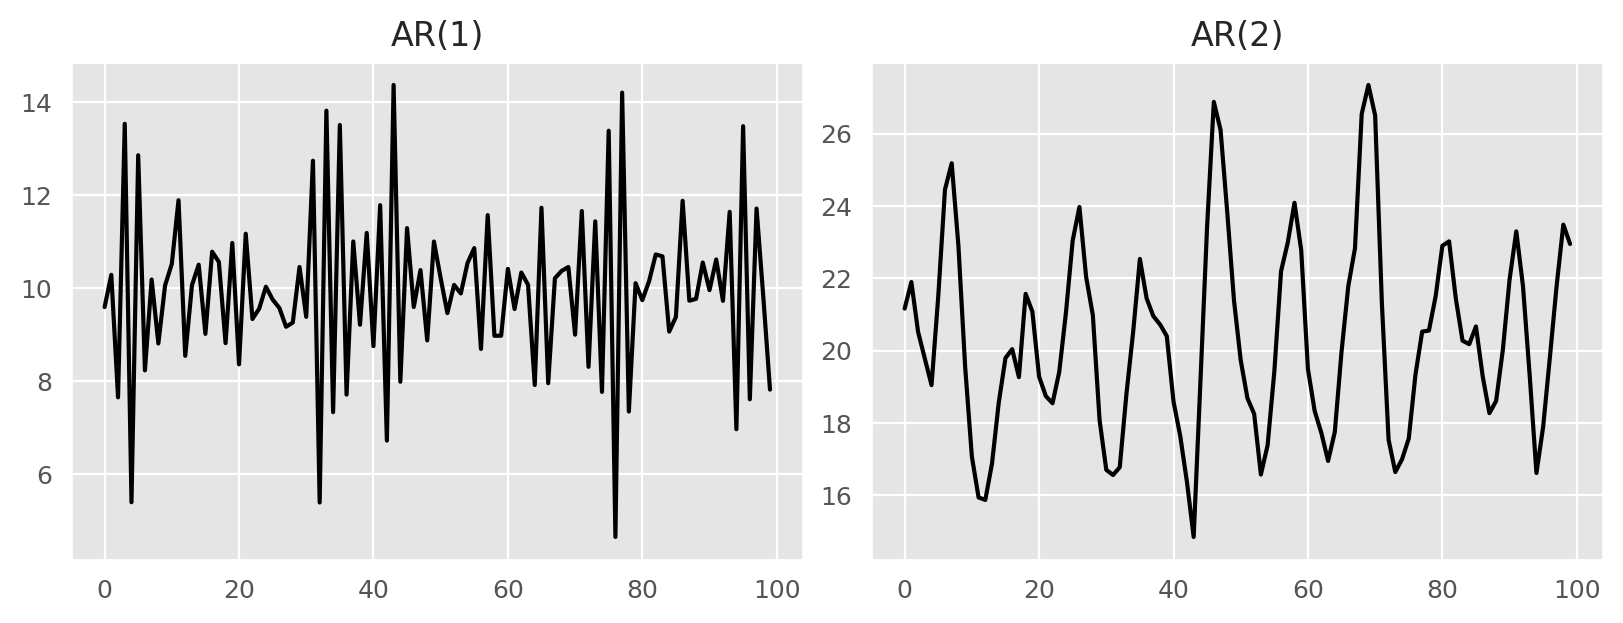

Figure 9.5: Two examples of data from autoregressive models with different parameters. Left: AR(1) with $y_t = 18 - 0.8y_{t-1} + \epsilon_t$. Right: AR(2) with $y_t = 8 + 1.3y_{t-1} - 0.7y_{t-2} + \epsilon_t$ . In both cases, $\epsilon_t$ is normally distributed white noise with mean zero and variance one.

For an AR(1) model:

* when $\phi_1 = 0$ and $c=0$ is equivalent to white noise;
* when $\phi_1 = 1$ and $c=0$ is equivalent to a random walk;
* when $\phi_1 = 1$ and $c!=0$ is equivalent to a random walk with drift;
* when $\phi_1 < 0$, tends to oscillate around the mean.

We normally restrict autoregressive models to stationary data, in which case some constraints on the values of the parameters are required.

* For an AR(1) model: $-1 < \phi_1 < 1$
* For an AR(2) model: $-1 < \phi_2 < 1, \phi_1 + \phi_2 < 1, \phi_2 - \phi_1 < 1$

When $p≥3$, the restrictions are much more complicated, however software packages such as `statsforecast` take care of that.

## 9.3 Moving average models

Rather than using past values of the forecast variable in a regression, a moving average model uses past forecast errors in a regression-like model, $$y_t = c + \epsilon_t + \theta_1\epsilon_{t-1} + \theta_2\epsilon_{t-2}+...+ \theta_q\epsilon_{t-q}$$
* where $\epsilon_t$ is white noise. We refer to this as an **MA($q$)** model, a moving average model of order $q$.

In simple words we can say the current value of the time series will depend on the past $q$ error terms

Notice that each value of $y_t$ can be thought of as a weighted moving average of the past few forecast errors (although the coefficients will not normally sum to one). However, moving average models should not be confused with the moving average smoothing we discussed in Chapter 3. A moving average model is used for forecasting future values, while moving average smoothing is used for estimating the trend-cycle of past values.
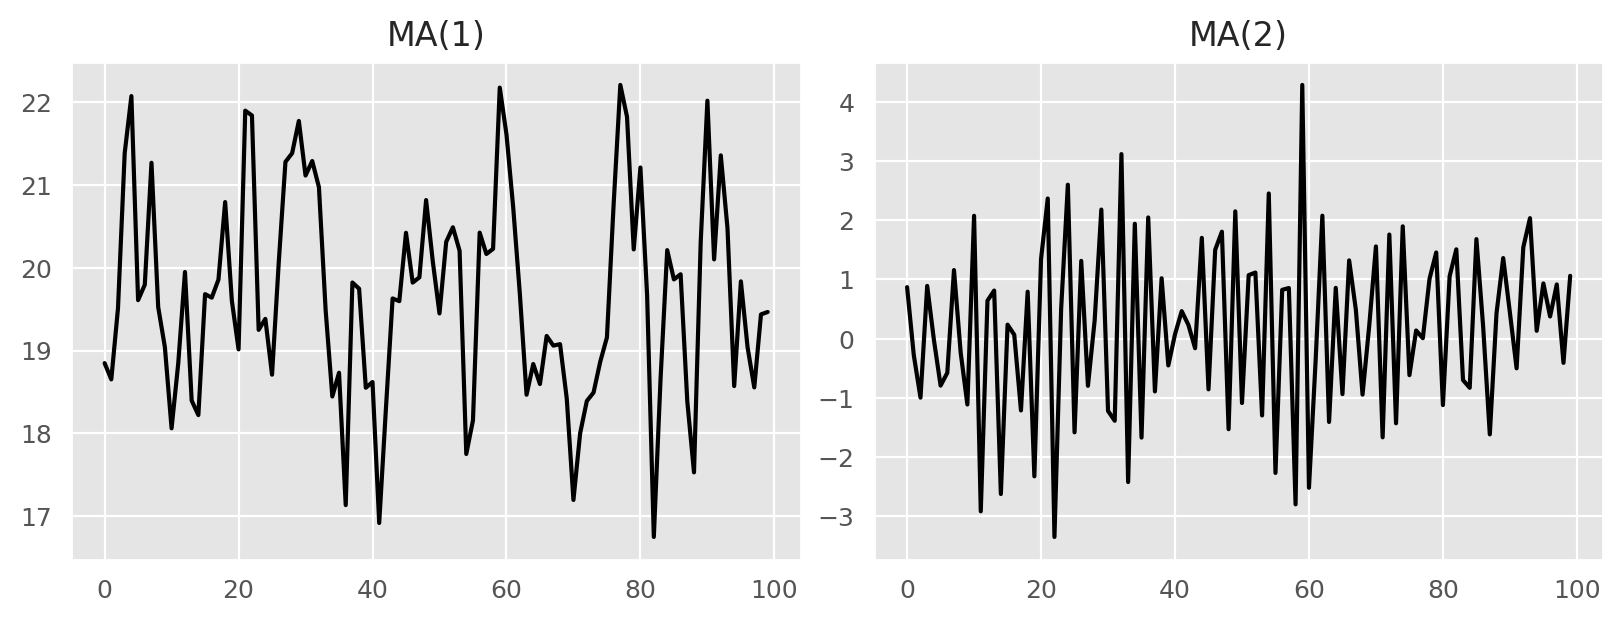
> Figure 9.6: Two examples of data from moving average models with different parameters. Left: MA(1) with $y_t = 20 + \epsilon_t + 0.8\epsilon_{t-1}$. Right: MA(2) with $y_t = \epsilon - \epsilon_{t-1} + 0.8\epsilon_{t-2} $ is normally distributed white noise with mean zero and variance one.

It is possible to write any stationary AR($p$) model as an MA($∞$) model. For example, using repeated substitution, we can demonstrate this for an AR(1) model: $$$$

## 9.4 Non-seasonal ARIMA models

If we combine differencing with autoregression and a moving average model, we obtain a non-seasonal ARIMA model. ARIMA is an acronym for AutoRegressive Integrated Moving Average (in this context, “integration” is the reverse of differencing). The full model can be written as $$y'_t = c + \phi_1y'_{t-1}+...+\phi_py'_{t-p}+\theta_1\epsilon_{t-1}+...+\theta_q\epsilon_{t-q}+\epsilon_t ~~~~~~(1)$$
* Where $y'_t$ is the differeced series  (it may have been differenced more than once). The “predictors” on the right hand side include both lagged values of $y_t$ and lagged errors. We call this an **ARIMA($p,d,q$)** model, where
    * $p =$ order of the autoregressive part;
    * $d =$ degree of first differencing involved;
    * $q =$ order of the moving average part.

The same stationarity and invertibility conditions that are used for autoregressive and moving average models also apply to an ARIMA model.

Many of the models we have already discussed are special cases of the ARIMA model:
|Special case|ARIMA($p,d,q$)|
|--|--|
|White noise|ARIMA(0,0,0) with no constant|
|Random walk|ARIMA(0,1,0) with no constant|
|Random walk with drift|ARIMA(0,1,0) with a constant|
|Autoregression|ARIMA($p$,0,0)|
|Moving average|ARIMA(0,0,$q$)|

Once we start combining components in this way to form more complicated models, it is much easier to work with the backshift notation. For example, Equation (1) can be written in backshift notation as
$$\underset{\substack{\uparrow \\ \text{AR}(p)}}{(1 - \phi_1 B - \dots - \phi_p B^p)} 
\underset{\substack{\uparrow \\ d \text{ differences}}}{(1 - B)^d y_t} 
= c + 
\underset{\substack{\uparrow \\ \text{MA}(q)}}{(1 + \theta_1 B + \dots + \theta_q B^q)} \varepsilon_t$$

Selecting appropriate values for p, d and q can be difficult. However, the `AutoARIMA()` function from the `statsforecast` package will do it for you automatically.

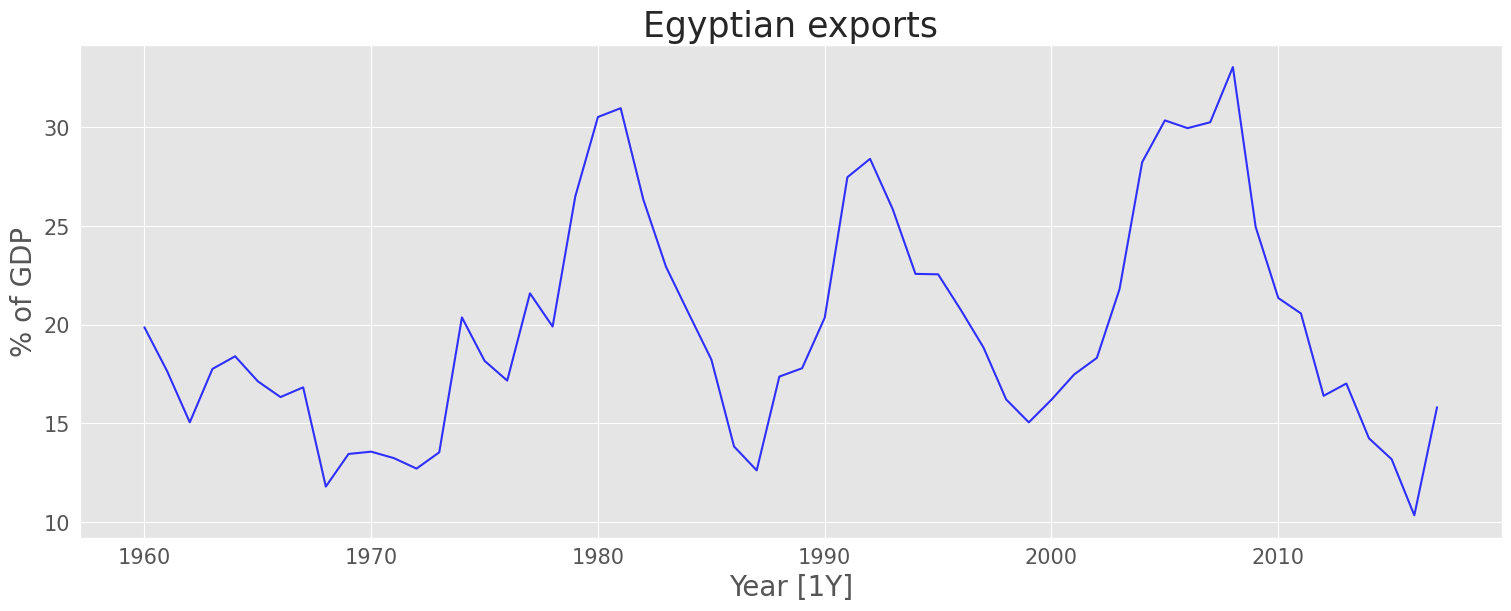

In [13]:
egyptian_economy = (
    pd.read_csv(DATA_DIR / "global_economy.csv", parse_dates=[2])
    .rename(columns={"Exports": "y"})
    .loc[lambda x: x["Code"] == "EGY"]
    [["ds", "y", "unique_id"]]
)

plot_series(egyptian_economy,
    xlabel="Year [1Y]", ylabel="% of GDP", title="Egyptian exports")

In [14]:
models = [AutoARIMA(allowmean=True)]
sf = StatsForecast(models=models, freq="A", n_jobs=-1)
sf.fit(df=egyptian_economy)

model = sf.fitted_[0, 0].model_
coefs = {**model["coef"]}
coefs["mean"] = coefs.pop("intercept")
coefs = {k: round(v, 3) for k, v in coefs.items()}
coefs = pd.Series(coefs, name="Coefficients").round(3)
metrics = pd.Series({
    "sigma^2": model["sigma2"], "loglik": model["loglik"],
    "aic": model["aic"], "aicc": model["aicc"], "bic": model["bic"],
}, name="Metrics").round(2)

print(ARIMASummary(model), "\n")
print(coefs.to_frame(), "\n")
print(metrics.to_frame())

ARIMA(2,0,1) with non-zero mean 

      Coefficients
ar1          1.676
ar2         -0.803
ma1         -0.690
mean        20.179 

         Metrics
sigma^2     8.05
loglik   -141.57
aic       293.13
aicc      294.29
bic       303.43


This is an ARIMA(2,0,1) model: $$y_t = c + 1.68y_{t-1} - 0.8y_{t-2} - 0.69\epsilon_{t-1}+\epsilon_t$$
* where $c = 20.18 \times (1-1.68+0.8) = 2.43$ and $\epsilon_t$ is white noise with a stanard deviation of $2.837 = \sqrt{8.046}$

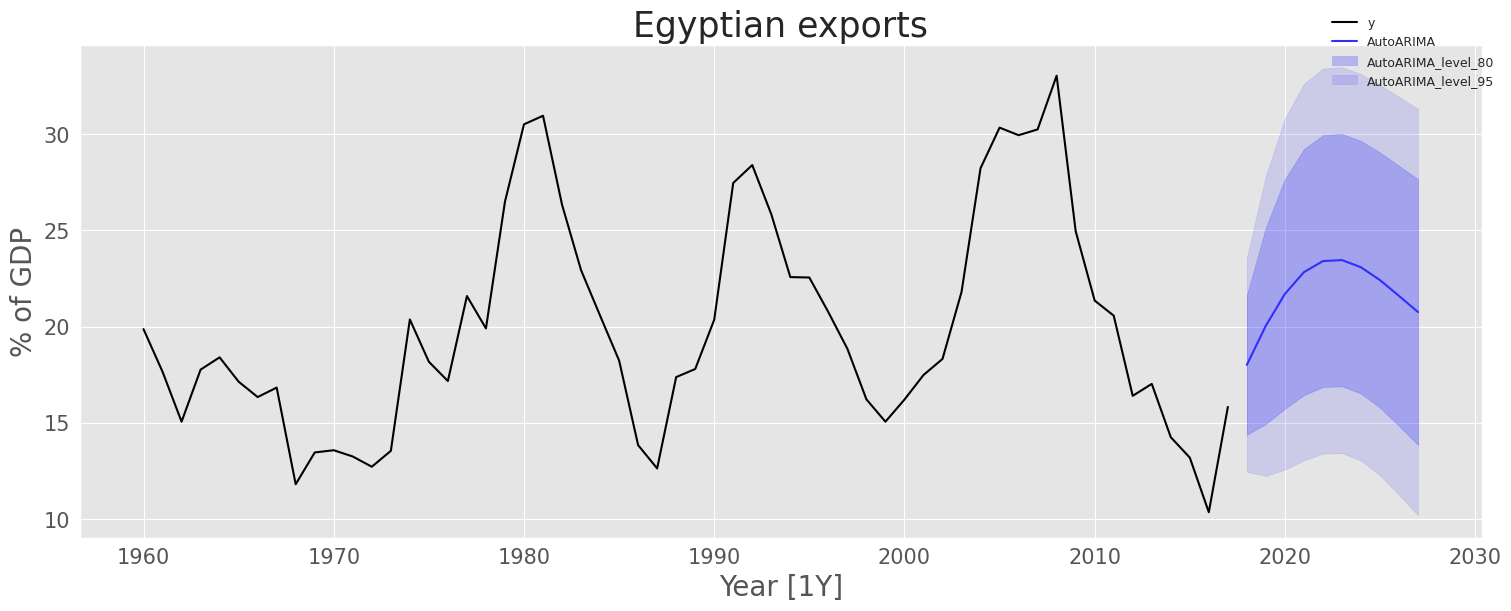

In [15]:
levels = [80, 95]
fc = sf.predict(h=10, level=levels)
plot_series(egyptian_economy, fc, level=levels,
    xlabel="Year [1Y]", ylabel="% of GDP", title="Egyptian exports",
    palette="black_and_blue", rm_legend=False,)

### Understanding ARIMA models 

The constant $c$ has an important effect on the long-term forecasts obtained from these models.

* If $c=0$ and $d=0$, the long-term forecasts will go to zero.
* If $c=0$ and $d=1$, the long-term forecasts will go to a non-zero constant.
* If $c=0$ and $d=2$, the long-term forecasts will follow a straight line.
* If $c\neq0$ and $d=0$, the long-term forecasts will go to the mean of the data.
* If $c\neq0$ and $d=1$, the long-term forecasts will follow a straight line.
* If $c\neq0$ and $d=2$, the long-term forecasts will follow a quadratic trend. (This is not recommended.)


### ACF and PACF plots

It is usually not possible to tell, simply from a time plot, what values of p and q are appropriate for the data. However, it is sometimes possible to use the ACF plot, and the closely related PACF plot, to determine appropriate values for p and q.

Recall that an ACF plot shows the autocorrelations which measure the relationship between $y_t$ and $y_{t-1}$ for different values of $k$. Now if $y_t$ and $y_{t-1}$ are correlated, then $y_{t-1}$ and $y_{t-2}$ must also be correlated. However, then $y_t$ and $y_{t-2}$ might be correlated, simply because they are both connected to $y_{t-1}$, rather than because of any new information contained in $y_{t-2}$ that could be used in forecasting $y_{t}$.

To overcome this problem, we can use partial autocorrelations. These measure the relationship between $y_t$ and $y_{t-k}$ after removing the effects of lags $1,2,3,…,k−1$. So the first partial autocorrelation is identical to the first autocorrelation, because there is nothing between them to remove. Each partial autocorrelation can be estimated as the last coefficient in an autoregressive model. Specifically, $\alpha_k$, the $k$th partial autocorrelation coefficient, is equal to the estimate of $\phi_k$ in an AR($k$) model. 

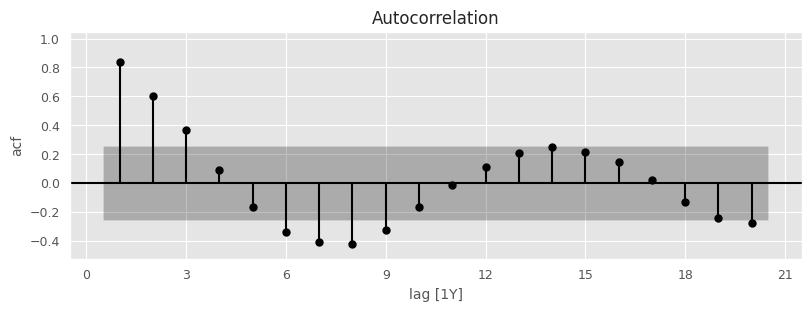

In [16]:
# shows the ACF and PACF plots for the Egyptian exports data
fig, ax = plt.subplots(figsize=(8, 3))
plot_acf(
    egyptian_economy["y"], lags=20, zero=False,
    bartlett_confint=False, ax=ax, auto_ylims=True)
ax.xaxis.set_major_locator(MaxNLocator(integer=True))
ax.set(xlabel="lag [1Y]", ylabel="acf")
plt.show()

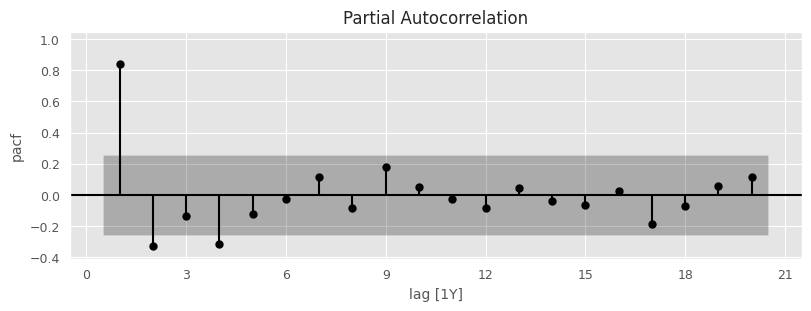

In [17]:
fig, ax = plt.subplots(figsize=(8, 3))
fig = plot_pacf(
    egyptian_economy["y"], lags=20, zero=False,
    ax=ax, auto_ylims=True)
ax.xaxis.set_major_locator(MaxNLocator(integer=True))
ax.set(xlabel="lag [1Y]", ylabel="pacf")
plt.show()

## 9.5 Estimation and order selection 

### Maximum likelihood estimation

## 9.6 ARIMA modelling in `statsforecast`?

### How does `AutoARIMA` work?

`AutoARIMA()` uses a variation of the Hyndman-Khandakar algorithm (Hyndman & Khandakar, 2008), which combines unit root tests, minimisation of the AICc and MLE to obtain an ARIMA model. The arguments to `ARIMA()` provide for many variations on the algorithm. What is described here is the default behaviour.

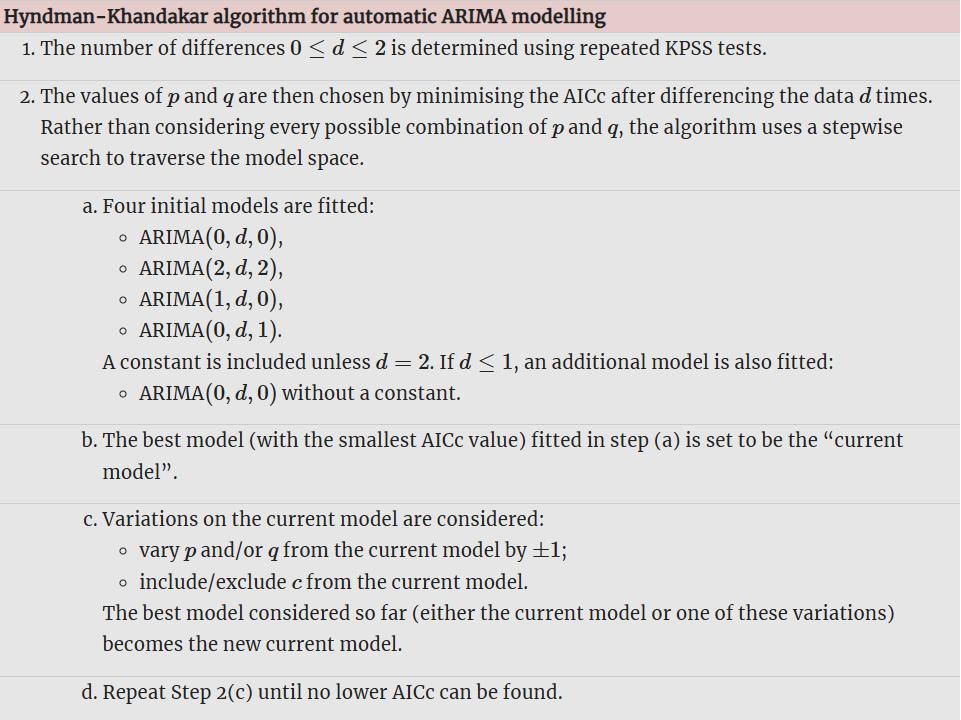


### Modelling procedure

When fitting an ARIMA model to a set of (non-seasonal) time series data, the following procedure provides a useful general approach.

1. Plot the data and identify any unusual observations.
2. If necessary, transform the data (using a Box-Cox transformation) to stabilise the variance.
3. If the data are non-stationary, take first differences of the data until the data are stationary.
4. Examine the ACF/PACF: Is an ARIMA($p,d,0$) or ARIMA($0,d,q$) model appropriate?
5. Try your chosen model(s), and use the AICc to search for a better model.
6. Check the residuals from your chosen model by plotting the ACF of the residuals, and doing a portmanteau test of the residuals. If they do not look like white noise, try a modified model.
7. Once the residuals look like white noise, calculate forecasts.

The Hyndman-Khandakar algorithm only takes care of steps 3–5. So even if you use it, you will still need to take care of the other steps yourself.

### Portmanteay tests of residuals for ARIMA models 

With ARIMA models, more accurate portmanteau tests are obtained if the degrees of freedom of the test statistic are adjusted to take account of the number of parameters in the model. Specifically, we use $\ell−K$ degrees of freedom in the test, where $K$ is the number of AR and MA parameters in the model. So for the non-seasonal models that we have considered so far, $K=p+q$. The value of $K$ is passed to the `acorr_ljungbox()` function via the argument model_df, as shown in the example below.

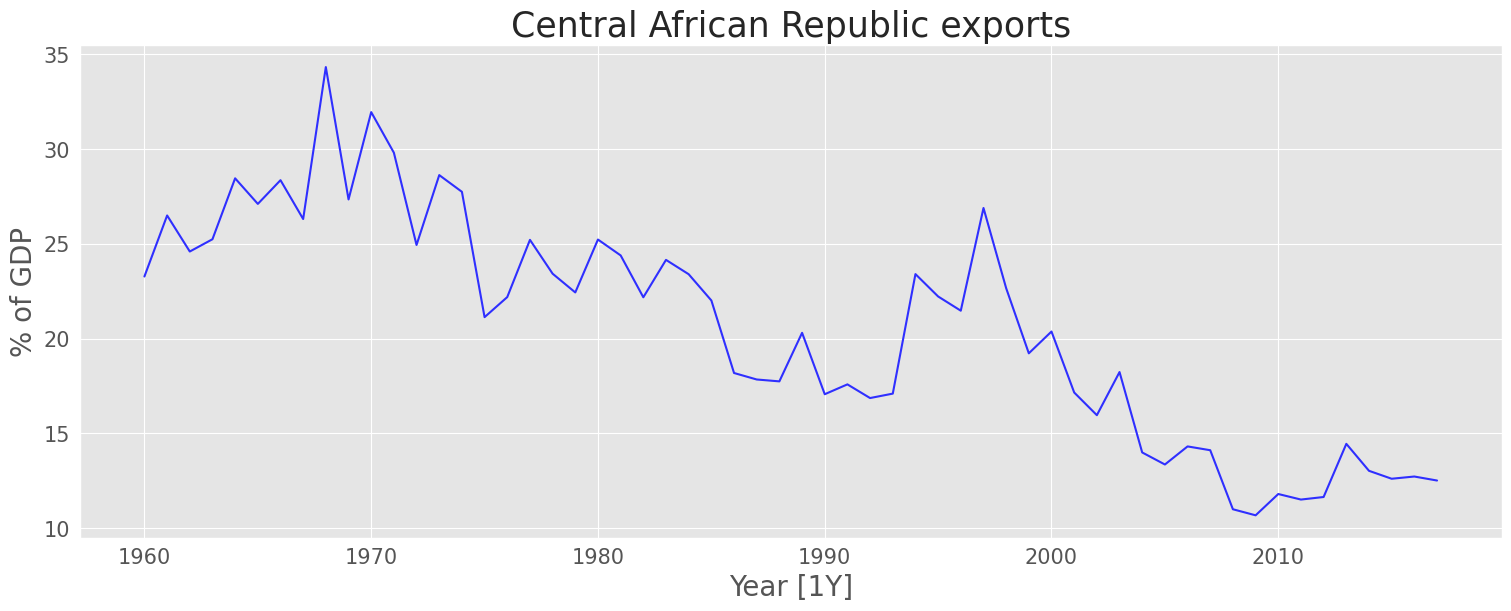

In [19]:
caf_economy = (
    pd.read_csv(DATA_DIR / "global_economy.csv", parse_dates=[2])
    .rename(columns={"Exports": "y"})
    .loc[lambda x: x["Code"] == "CAF"]
    [["unique_id", "ds", "y"]]
)

plot_series(caf_economy, xlabel="Year [1Y]", ylabel="% of GDP",
    title="Central African Republic exports")

1. The time plots shows some non-stationary, with an overall decline. 
2. There is no envidence of changing variance, so we will not do a Box-Cox transformation. 
3. To adress the non-stationary, we will take a first diffence of the data. 

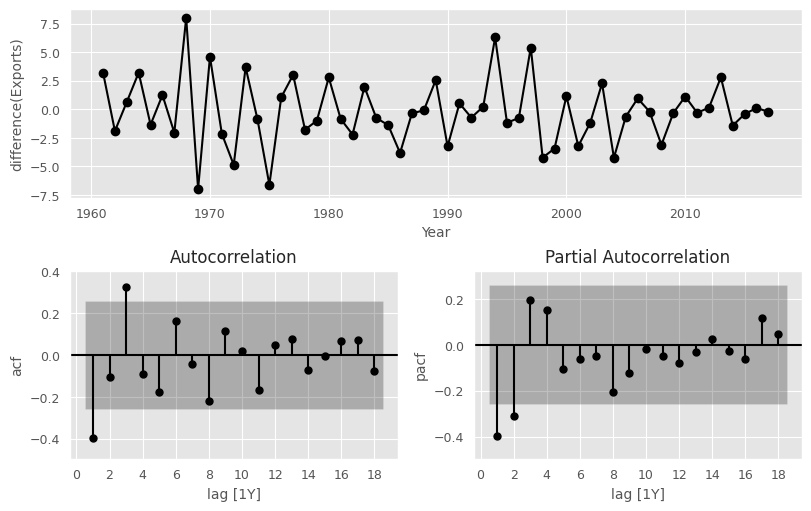

In [20]:
df = caf_economy.assign(diff=caf_economy["y"].diff()).iloc[1:]
fig, axes = plt.subplot_mosaic([["diff", "diff"], ["acf", "pacf"]])
axes["diff"].plot(df["ds"], df["diff"], marker="o")
axes["diff"].set(xlabel="Year", ylabel="difference(Exports)")
plot_acf(df["diff"], axes["acf"],
    zero=False, auto_ylims=True, bartlett_confint=False)
plot_pacf(df["diff"], axes["pacf"],
    zero=False, auto_ylims=True)
axes["acf"].set(xlabel="lag [1Y]", ylabel="acf")
axes["acf"].xaxis.set_major_locator(MaxNLocator(integer=True))
axes["pacf"].set(xlabel="lag [1Y]", ylabel="pacf")
axes["pacf"].xaxis.set_major_locator(MaxNLocator(integer=True))
plt.show()

4. The PACF plot is sugesstive of an AR(2) model, so an initial candidate model is an ARIMA(2,1,0). The ACF suggests an MA(3), so an alternative candidate model is an ARIMA(0,1,3).
5. We fit both an ARIMA(2,1,0) and an ARIMA(0,1,3) model along with two automated model selections, one using the default stepwise procedure, and one working harder to search a larger model space.

In [21]:
models = [
    ARIMA(order=(2, 1, 0), alias="arima210"),
    ARIMA(order=(0, 1, 3), alias="arima013"),
    AutoARIMA(alias="stepwise"),
    AutoARIMA(stepwise=False, alias="search"),
]
sf = StatsForecast(models=models, freq="A", n_jobs=-1)
sf.fit(caf_economy)
summaries = []
for model in sf.fitted_[0]:
    summary_model = {
        "model": model,
        "Orders": ARIMASummary(model.model_),
        "sigma2": model.model_["sigma2"],
        "loglik": model.model_["loglik"],
        "aic": model.model_["aic"],
        "aicc": model.model_["aicc"],
        "bic": model.model_["bic"],
    }
    summaries.append(summary_model)
pd.DataFrame(sorted(summaries, key=lambda d: d["aicc"]))

,model,Orders,sigma2,loglik,aic,aicc,bic
0,search,"ARIMA(3,1,0)",6.519,-133.006,274.012,274.781,282.184
1,arima210,"ARIMA(2,1,0)",6.706,-134.269,274.539,274.992,280.668
2,arima013,"ARIMA(0,1,3)",6.537,-133.130,274.261,275.030,282.433
3,stepwise,"ARIMA(2,1,2)",6.417,-132.124,274.248,275.425,284.463


> We can see that an ARIMA(3,1,0) gives the lowest AICc value. 

6. The ACF plot of the residuals from the ARIMA(3,1,0) model shows that all autocorrelations are within the threshold limits, indicating that the residuals are behaving like white noise.

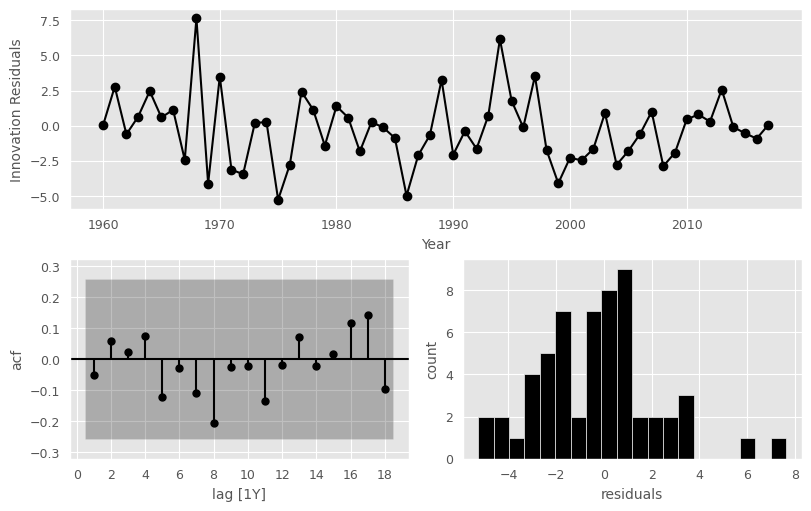

In [23]:
fc = sf.forecast(df=caf_economy, h=10, fitted=True, level=[80, 95])
insample = sf.forecast_fitted_values()
residuals = insample["y"] - insample["search"]

fig, axes = plt.subplot_mosaic([["resid", "resid"], ["acf", "hist"]])
axes["resid"].plot(caf_economy["ds"], residuals, marker="o")
axes["resid"].set(xlabel="Year", ylabel="Innovation Residuals")
plot_acf(residuals, axes["acf"], zero=False, auto_ylims=True,
    bartlett_confint=False)
axes["acf"].xaxis.set_major_locator(MaxNLocator(integer=True))
axes["acf"].set(xlabel="lag [1Y]", ylabel="acf", title="")
axes["hist"].hist(residuals, bins=20)
axes["hist"].set(xlabel="residuals", ylabel="count")
plt.show()

A portmanteau test (setting $K=3$) returns a large p-value, also suggesting that the residuals are white noise.

In [24]:
ljung_box = acorr_ljungbox(residuals, lags=[10], model_df=3)
ljung_box

,lb_stat,lb_pvalue
10,5.704,0.575


7. Forecasts from the chosen model.
> Note that the mean forecasts look very similar to what we would get with a random walk (equivalent to an ARIMA(0,1,0)). The extra work to include AR and MA terms has made little difference to the point forecasts in this example, although the prediction intervals are much narrower than for a random walk model.

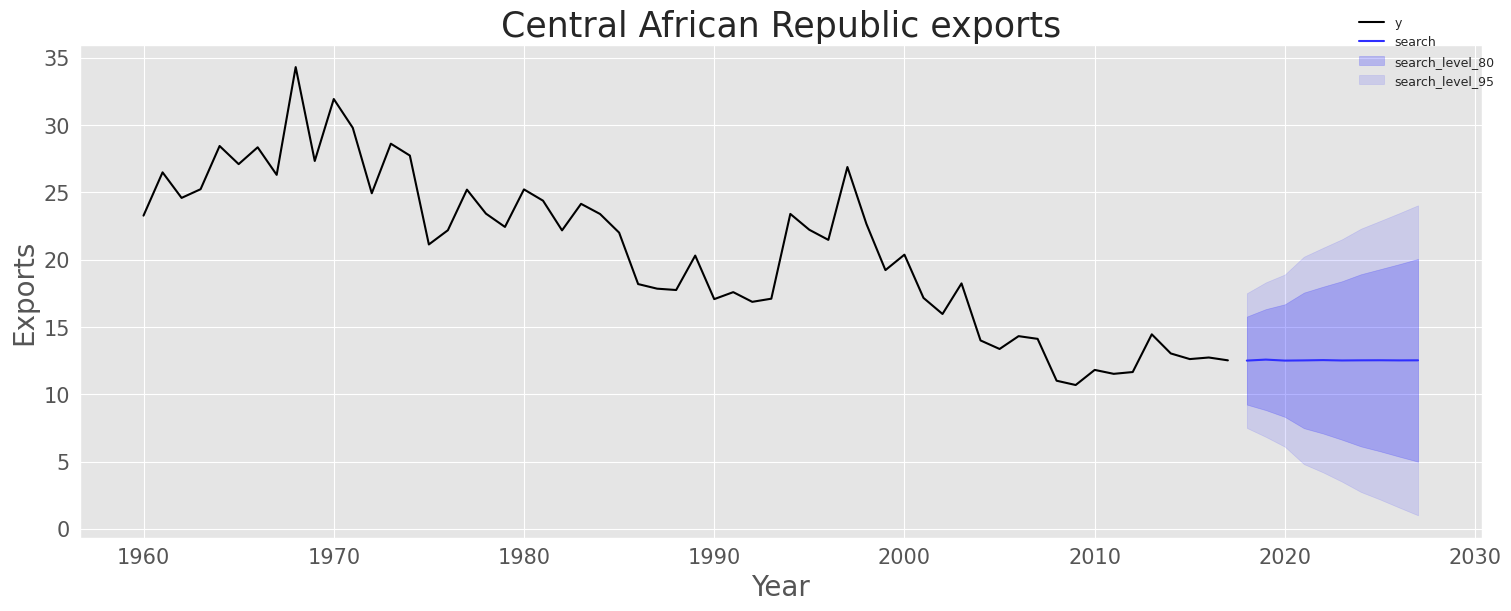

In [26]:
search_columns = fc.columns[fc.columns.str.startswith("search")]
search_fc = fc[["unique_id", "ds", *search_columns]]
plot_series(caf_economy, search_fc, level=[80, 95],
    xlabel="Year", ylabel="Exports",
    title="Central African Republic exports",
    palette="black_and_blue", rm_legend=False,)

### Understanding constants

A non-seasonal ARIMA model can be written as $$(1 - \phi B - ... - \phi_p B^p)(1-B)^dy_t = c + (1+ \theta_1B + ...+ \theta_q B^q)\epsilon_t$$
* Where $c = \mu(1 - \phi_1 - ... - \phi_p)$ and $\mu$ is the mean of $(1-B)^d y_t$

This is an excellent, technically dense section of time series theory. When we talk about "constants" in ARIMA, we are essentially talking about the **long-term growth assumption** of your model.

In essence, the constant dictates whether your forecast eventually levels off, returns to a historical average, or keeps trending upward indefinitely.


#### The Behavior of Long-Term Forecasts

This is the most critical part for practical forecasting. You can think of the constant ($c$) and the differencing ($d$) as defining the **"shape" of your forecast’s tail.**

* **When $d=0$ (Stationary):** You are telling the model, "The data stays around a fixed level." If you include a constant, that level is the historical mean. If you set $c=0$, you are forcing the model to believe the long-term average is zero.
* **When $d=1$ (Random Walk):** You are telling the model, "The *change* between points is stable." If you add a constant ($c \neq 0$), that constant acts as "drift"—a steady, linear increase or decrease over time.
* **When $d=2$ (Trended):** This is rarely used in practice. Including a constant here creates a **quadratic trend** (an accelerating curve, like a rocket taking off). This is usually "explosive" and highly unrealistic for most business time series, which is why software strictly forbids it.

---

#### Software Logic (StatsForecast & AutoARIMA)

Modern libraries like `StatsForecast` prioritize **parsimony** (keeping models simple) and **stability**.

* **Why disable constants for $d>1$?** As mentioned above, a constant with $d=2$ creates a quadratic trend ($t^2$). A quadratic trend is dangerous because it assumes the rate of growth itself is growing. In nearly all real-world business contexts (sales, inventory, demand), this will lead to absurdly high or low forecasts that don't reflect reality.
* **The "Default" behavior:** The reason `include_mean=True` is default for $d=0$ is that most stationary data has a non-zero mean. If you forced it to zero, your forecast would be biased. However, for $d \geq 1$, the default is usually `False` because "drift" is a strong assumption. You are essentially telling the model, "I *know* for a fact this data is going to keep trending upward forever," which is a huge claim to make without data evidence.

### Summary Table for your Mental Toolbox

| Order of Differencing ($d$) | Constant State | Long-Term Forecast Behavior |
| --- | --- | --- |
| **$d=0$** | $c \neq 0$ | Returns to historical mean |
| **$d=0$** | $c = 0$ | Returns to zero |
| **$d=1$** | $c \neq 0$ | Linear Trend (Drift) |
| **$d=1$** | $c = 0$ | Flat Line (Random Walk) |
| **$d=2$** | $c \neq 0$ | Quadratic Trend (Dangerous) |
| **$d=2$** | $c = 0$ | Linear Trend |

**Pro Tip:** If your data has a clear trend, using $d=1$ with `include_drift=True` is a very standard way to model it. But if you see your forecast taking off in an accelerating curve, check if your software has accidentally enabled a constant for a $d=2$ model!

## 9.7 Forecasting 

### Point forecasts

Point forecasts can be calculated using the following three steps:
1. Expand the ARIMA equation so that $y_t$ is on the left hand side and all other terms are on the right.
2. Rewrite the equation by replacing $t$ with $T+h$
3. On the right hand side of the equation, replace future observations with their forecasts, future errors with zero, and past errors with the corresponding residuals.

### Prediction intervals

The prediction intervals for ARIMA models are based on assumptions that the residuals are uncorrelated and normally distributed. If either of these assumptions does not hold, then the prediction intervals may be incorrect. For this reason, always plot the ACF and histogram of the residuals to check the assumptions before producing prediction intervals.

If the residuals are uncorrelated but not normally distributed, then bootstrapped intervals can be obtained instead.


## 9.8 Seasonal ARIMA models 

So far, we have restricted our attention to non-seasonal data and non-seasonal ARIMA models. However, ARIMA models are also capable of modelling a wide range of seasonal data.


